# Question 3 (10 marks)

1. Given a start-point, a goal point, and two obstacles (defined in the provided code), implement the artificial potential field method to plan a collision-free trajectory from the starting point to the target point, while avoiding the two obstacles.
2. Visualize the planned trajectory, clearly showing the start point, target point, obstacles, and the path generated by your planner.

In [1]:
# import necessary python packages
import torch
import matplotlib.pyplot as plt

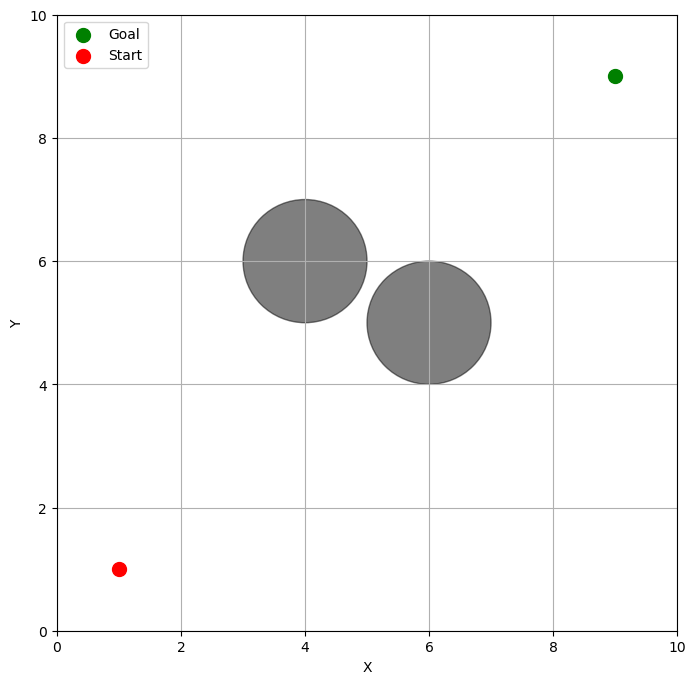

In [2]:
# Parameters for the environment
Goal = torch.tensor([9.0, 9.0], dtype=torch.float32)  # goal position
Start = torch.tensor([1.0, 1.0], dtype=torch.float32)  # start position

Obstacles = torch.tensor([[4.0, 6.0], [6.0, 5.0]], dtype=torch.float32)  # obstacle positions
Obstacle_radius = 1  # radius of the circular obstacles
Threshold = 4 # Threshold (i.e., rho_0), typically larger than Obstacle_radius

# Plotting the environment
plt.figure(figsize=(8, 8))
plt.scatter(Goal[0], Goal[1], color="green", label="Goal", s=100)
plt.scatter(Start[0], Start[1], color="red", label="Start", s=100)
for obs in Obstacles.numpy():
    circle = plt.Circle((obs[0], obs[1]), Obstacle_radius, color="black", alpha=0.5)
    plt.gca().add_artist(circle)
# Create a grid environment
grid_size = 10  # size of the grid
plt.xlim(0, grid_size)
plt.ylim(0, grid_size)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [3]:
# parameters for attractive force and repulsive force
k_att = 1.0  # attractive constant
k_rep = 100.0  # repulsive constant

# Attractive potential field (towards goal)
def attractive_potential(x, goal):
    return 0.5 * k_att * torch.norm(x - goal) ** 2

# Repulsive potential field (away from obstacles)
def repulsive_potential(x, obstacles, threshold):
    rep_total = 0
    for obs in obstacles:
        dist = torch.norm(x - obs)
        if dist <= threshold:
            potential = 0.5 * k_rep * (1.0 / dist - 1.0 / threshold) ** 2
        else:
            potential = torch.tensor(0.0)  # zero if distance > threshold (means the robot is far from the obstacle)
        rep_total += potential
    return rep_total

Goal reached in 146 iterations!


c:\Users\Abdua\anaconda3\envs\lettuce\Lib\site-packages\torch\functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3610.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


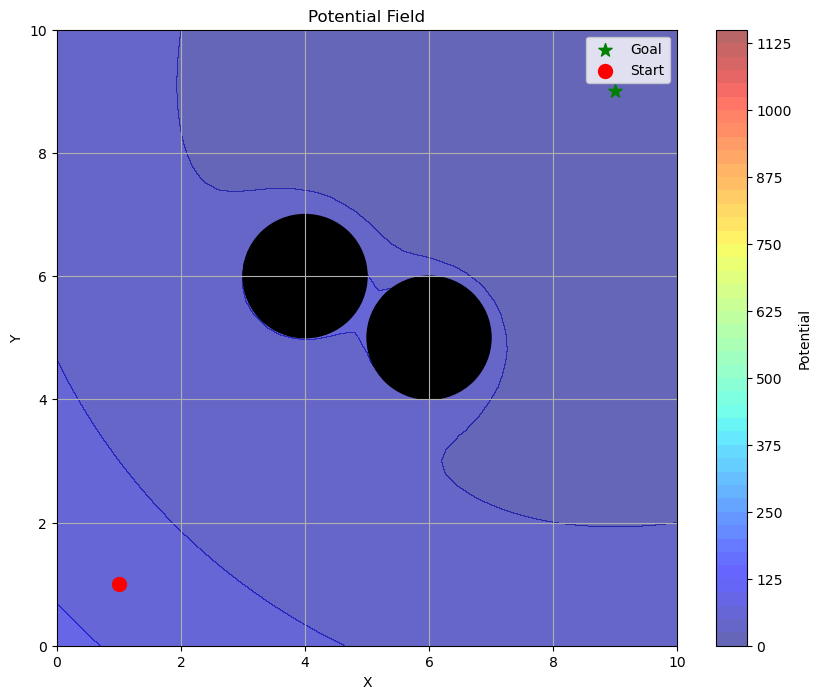

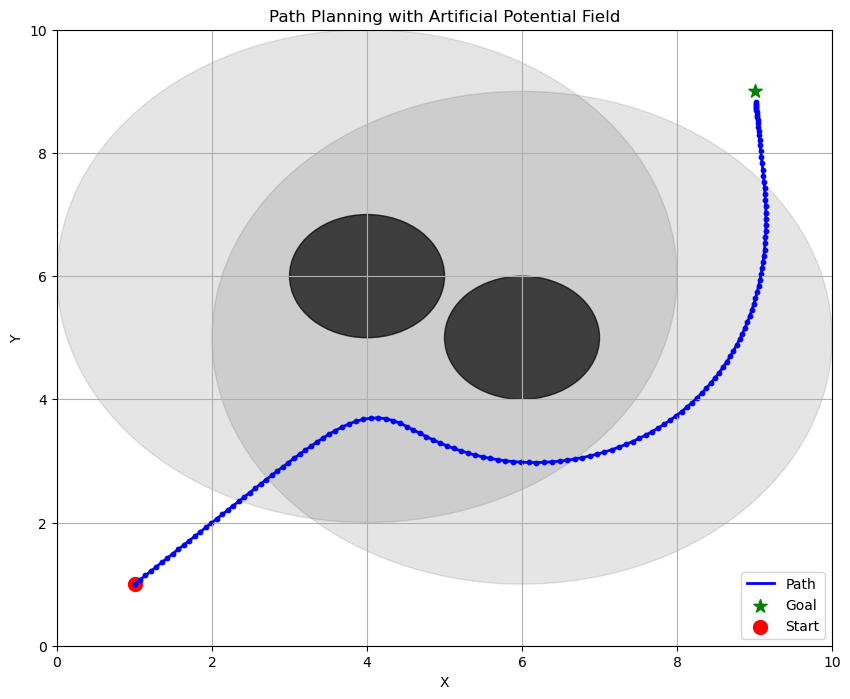

Path length: 147 points
Total distance traveled: 13.79


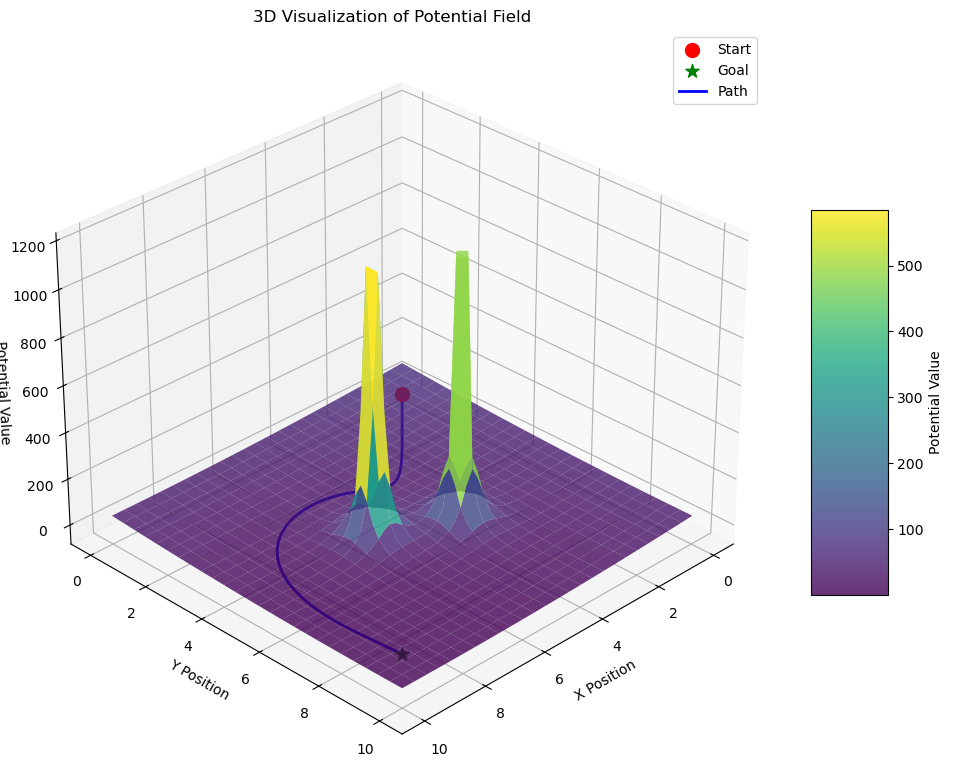

In [4]:
# TODO: implement your code here, where you can use the above two provided functions

# Implementation of force calculation using the provided potential functions
def attractive_force(x, goal):
    """Calculate the attractive force towards the goal."""
    # Force is the negative gradient of the potential
    # For quadratic potential, gradient is proportional to distance
    return -k_att * (x - goal)

def repulsive_force(x, obstacles, threshold):
    """Calculate the repulsive force away from obstacles."""
    force = torch.zeros_like(x)
    for obs in obstacles:
        dist = torch.norm(x - obs)
        if dist <= threshold:
            # Direction from obstacle to point (unit vector)
            direction = (x - obs) / dist
            # Repulsive force magnitude (negative gradient of repulsive potential)
            magnitude = k_rep * (1.0/dist - 1.0/threshold) * (1.0/dist**2)
            # Add the force
            force += magnitude * direction
    return force

def total_force(x, goal, obstacles, threshold):
    """Calculate the total force (attractive + repulsive)."""
    att = attractive_force(x, goal)
    rep = repulsive_force(x, obstacles, threshold)
    return att + rep
# Path planning using gradient descent
def plan_path(start, goal, obstacles, threshold, step_size=0.1, max_iterations=5000, goal_threshold=0.2):
    """
    Plan a path from start to goal using artificial potential field.
    
    Args:
        start: Starting position
        goal: Goal position
        obstacles: List of obstacle positions
        threshold: Distance threshold for repulsive field
        step_size: Step size for gradient descent
        max_iterations: Maximum number of iterations
        goal_threshold: Distance to goal considered as reached
        
    Returns:
        path: List of positions on the path
    """
    path = [start]
    current = start.clone()
    
    for i in range(max_iterations):
        # Calculate total force
        force = total_force(current, goal, obstacles, threshold)
        
        # Normalize the force if it's too large
        force_norm = torch.norm(force)
        if force_norm > 1.0:
            force = force / force_norm
        
        # Update position
        current = current + step_size * force
        
        # Add the new position to the path
        path.append(current.clone())
        
        # Check if goal is reached
        if torch.norm(current - goal) < goal_threshold:
            print(f"Goal reached in {i+1} iterations!")
            break
            
        # Check for local minimum (very small movement)
        if i > 0 and torch.norm(path[-1] - path[-2]) < 1e-5:
            print("Stuck in local minimum after", i, "iterations!")
            break
            
    if i == max_iterations - 1:
        print(f"Maximum iterations ({max_iterations}) reached without reaching the goal.")
        
    return torch.stack(path)


# Visualize the potential field
def plot_potential_field(start, goal, obstacles, threshold, resolution=0.2):
    """
    Plot the potential field on a grid.
    """
    x = torch.arange(0, grid_size + resolution, resolution)
    y = torch.arange(0, grid_size + resolution, resolution)
    
    potential = torch.zeros((len(x), len(y)))
    
    for i, xi in enumerate(x):
        for j, yj in enumerate(y):
            pos = torch.tensor([xi, yj], dtype=torch.float32)
            potential[i, j] = attractive_potential(pos, goal) + repulsive_potential(pos, obstacles, threshold)
    
    X, Y = torch.meshgrid(x, y)
    
    plt.figure(figsize=(10, 8))
    # Remove the .t() transpose operation
    contour = plt.contourf(X, Y, potential, 50, cmap='jet', alpha=0.6)
    plt.colorbar(contour, label='Potential')
    
    # Plot obstacles
    for obs in obstacles:
        circle = plt.Circle((obs[0], obs[1]), Obstacle_radius, color="black")
        plt.gca().add_patch(circle)
        
    # Plot start and goal
    plt.scatter(goal[0], goal[1], color="green", s=100, marker='*', label="Goal")
    plt.scatter(start[0], start[1], color="red", s=100, marker='o', label="Start")
    
    plt.xlim(0, grid_size)
    plt.ylim(0, grid_size)
    plt.grid(True)
    plt.title("Potential Field")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    
    return plt
# Execute the path planning
path = plan_path(Start, Goal, Obstacles, Threshold, step_size=0.1)

# Convert path to numpy for plotting
path_np = path.numpy()

# Plot potential field
plot_potential_field(Start, Goal, Obstacles, Threshold)
plt.show()

# Plot the environment and the path
plt.figure(figsize=(10, 8))

# Plot the path
plt.plot(path_np[:, 0], path_np[:, 1], 'b-', linewidth=2, label="Path")

# Plot start, goal and obstacles
plt.scatter(Goal[0], Goal[1], color="green", s=100, marker='*', label="Goal")
plt.scatter(Start[0], Start[1], color="red", s=100, marker='o', label="Start")

# Plot obstacles with their repulsive field
for obs in Obstacles.numpy():
    circle = plt.Circle((obs[0], obs[1]), Obstacle_radius, color="black", alpha=0.7)
    plt.gca().add_patch(circle)
    # Visualize the threshold (influence range)
    circle_threshold = plt.Circle((obs[0], obs[1]), Threshold, color="black", alpha=0.1)
    plt.gca().add_patch(circle_threshold)

# Add path points
plt.scatter(path_np[:, 0], path_np[:, 1], color='blue', s=10)

plt.grid(True)
plt.xlim(0, grid_size)
plt.ylim(0, grid_size)
plt.title("Path Planning with Artificial Potential Field")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

# Print path information
print(f"Path length: {len(path_np)} points")
print(f"Total distance traveled: {sum([torch.norm(path[i+1]-path[i]).item() for i in range(len(path)-1)]):.2f}")



def plot_potential_field_3d(start, goal, obstacles, threshold, resolution=0.2):
    """
    Plot the potential field as a 3D surface.
    """
    # Create a grid of points
    x = torch.arange(0, grid_size + resolution, resolution)
    y = torch.arange(0, grid_size + resolution, resolution)
    
    # Calculate potential at each point
    potential = torch.zeros((len(x), len(y)))
    for i, xi in enumerate(x):
        for j, yj in enumerate(y):
            pos = torch.tensor([xi, yj], dtype=torch.float32)
            potential[i, j] = attractive_potential(pos, goal) + repulsive_potential(pos, obstacles, threshold)
    
    # Create grid for surface plot
    X, Y = torch.meshgrid(x, y)
    Z = potential
    
    # Create 3D plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the surface
    surf = ax.plot_surface(X.numpy(), Y.numpy(), Z.numpy(), 
                          cmap='viridis', alpha=0.8, 
                          linewidth=0, antialiased=True)
    
    # Add colorbar
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Potential Value')
    
    # Mark start and goal on the surface
    start_z = attractive_potential(start, goal) + repulsive_potential(start, obstacles, threshold)
    goal_z = attractive_potential(goal, goal) + repulsive_potential(goal, obstacles, threshold)
    
    ax.scatter([start[0]], [start[1]], [start_z], color='red', s=100, label='Start')
    ax.scatter([goal[0]], [goal[1]], [goal_z], color='green', s=100, marker='*', label='Goal')
    
    # Mark obstacles
    for obs in obstacles:
        obs_z = attractive_potential(obs, goal) + repulsive_potential(obs, obstacles, threshold)
        ax.scatter([obs[0]], [obs[1]], [obs_z], color='black', s=100)
    
    # Plot the path in 3D
    path_z = []
    for point in path:
        z_val = attractive_potential(point, goal) + repulsive_potential(point, obstacles, threshold)
        path_z.append(z_val)
    
    path_np = path.numpy()
    ax.plot(path_np[:, 0], path_np[:, 1], path_z, 'b-', linewidth=2, label='Path')
    
    # Set labels and title
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_zlabel('Potential Value')
    ax.set_title('3D Visualization of Potential Field')
    
    # Set view angle for better visualization
    ax.view_init(elev=30, azim=45)
    
    # Add legend
    ax.legend()
    
    return fig

# Plot the potential field in 3D
fig_3d = plot_potential_field_3d(Start, Goal, Obstacles, Threshold)
plt.show()







# Discuss the results in your report

Experiment with different step size or learning rate for gradient descent, evaluate their performance. Then, analyze and discuss your findings in the report. You do not need to write code for this section—focus on interpreting and explaining the results in your discussion.

Maximum iterations (5000) reached without reaching the goal.
Goal reached in 2909 iterations!
Goal reached in 1455 iterations!
Goal reached in 291 iterations!
Goal reached in 146 iterations!
Goal reached in 33 iterations!
Goal reached in 23 iterations!
Goal reached in 20 iterations!
Goal reached in 19 iterations!
Maximum iterations (5000) reached without reaching the goal.
Maximum iterations (5000) reached without reaching the goal.
Maximum iterations (5000) reached without reaching the goal.


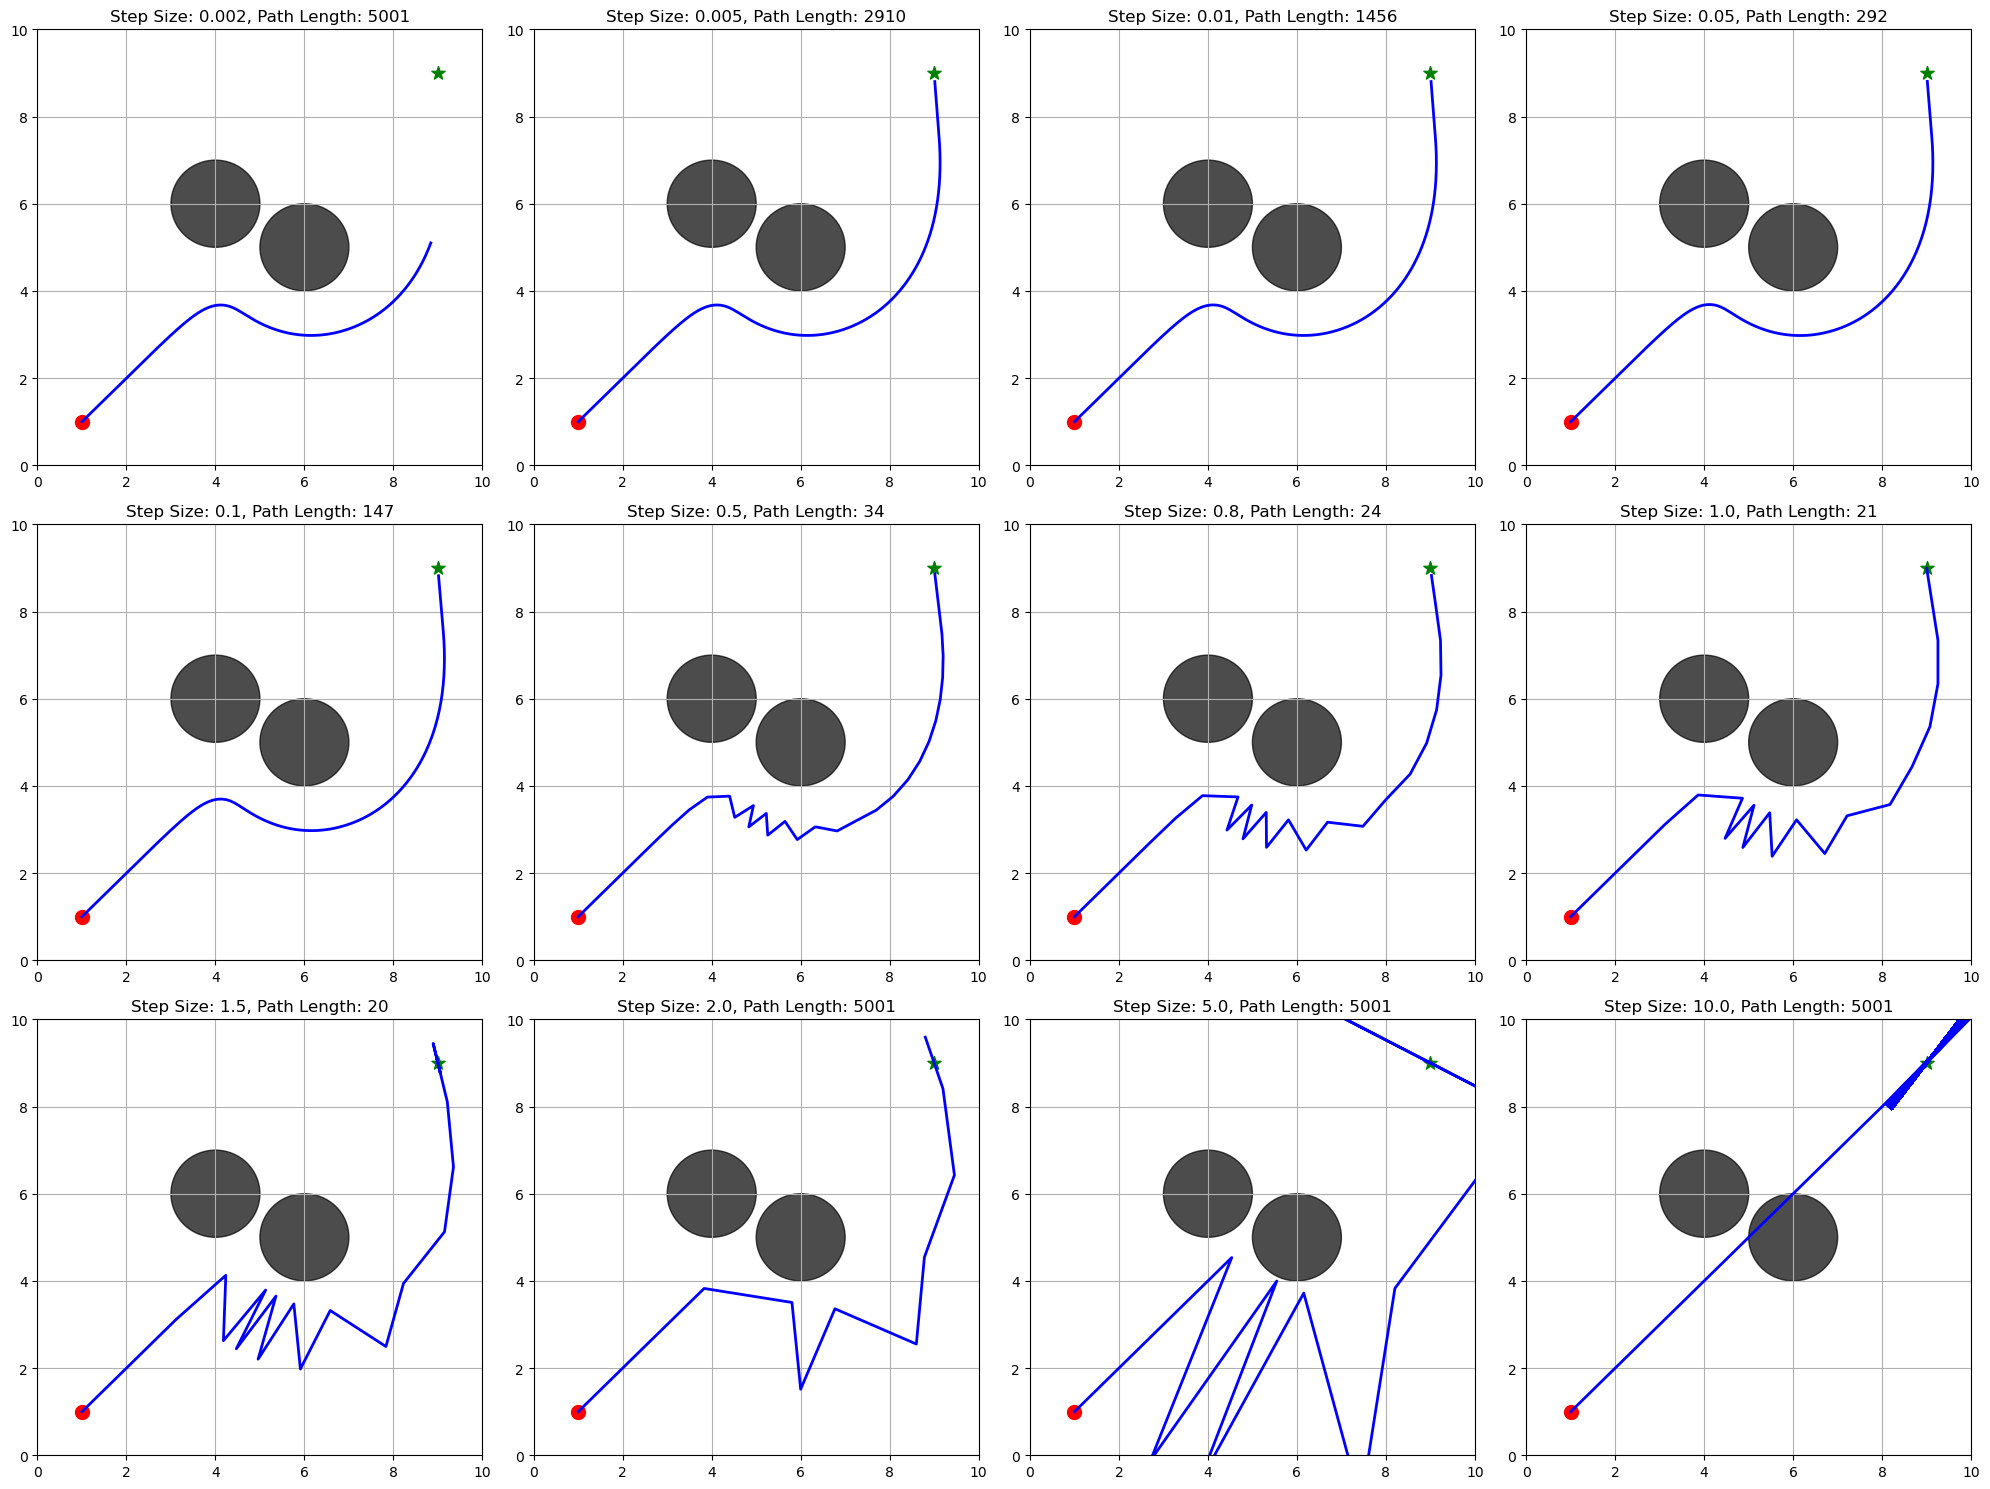

In [5]:
# TODO: discuss your results in your report (5 marks), no code required here, no code required for the report.


# Function to run path planning with different step sizes
def experiment_step_sizes(start, goal, obstacles, threshold, step_sizes=[0.05, 0.1, 0.2, 0.5]):
    """Run path planning with different step sizes and compare results."""
    results = []
    num_plots = len(step_sizes)
    
    # Determine grid layout based on number of plots
    if num_plots <= 3:
        rows, cols = 1, num_plots
    else:
        cols = min(4, num_plots)  # Maximum 4 columns
        rows = (num_plots + cols - 1) // cols  # Ceiling division
    
    # Adjust figure size based on grid layout
    fig_width = 5 * cols
    fig_height = 5 * rows
    
    for step in step_sizes:
        path = plan_path(start, goal, obstacles, threshold, step_size=step)
        path_length = len(path)
        total_distance = sum([torch.norm(path[i+1]-path[i]).item() for i in range(path_length-1)])
        
        results.append({
            'step_size': step,
            'path_length': path_length,
            'total_distance': total_distance,
            'path': path
        })
    
    # Plot comparison
    plt.figure(figsize=(fig_width, fig_height))
    
    for i, result in enumerate(results):
        plt.subplot(rows, cols, i+1)
        path_np = result['path'].numpy()
        
        # Plot the path
        plt.plot(path_np[:, 0], path_np[:, 1], 'b-', linewidth=2)
        
        # Plot start, goal and obstacles
        plt.scatter(goal[0], goal[1], color="green", s=100, marker='*')
        plt.scatter(start[0], start[1], color="red", s=100, marker='o')
        
        # Plot obstacles
        for obs in obstacles.numpy():
            circle = plt.Circle((obs[0], obs[1]), Obstacle_radius, color="black", alpha=0.7)
            plt.gca().add_patch(circle)
        
        plt.grid(True)
        plt.xlim(0, grid_size)
        plt.ylim(0, grid_size)
        plt.title(f"Step Size: {result['step_size']}, Path Length: {result['path_length']}")
    
    plt.tight_layout()
    plt.show()

# Example usage with different numbers of step sizes
experiment_step_sizes(Start, Goal, Obstacles, Threshold, [0.002, 0.005, 0.01, 0.05, 0.1, 0.5, 0.8, 1.0, 1.5, 2.0, 5.0, 10.0])

Maximum iterations (5000) reached without reaching the goal.
Goal reached in 2909 iterations!
Goal reached in 1455 iterations!
Goal reached in 727 iterations!
Goal reached in 291 iterations!
Goal reached in 146 iterations!
Goal reached in 33 iterations!
Goal reached in 23 iterations!
Goal reached in 20 iterations!
Goal reached in 19 iterations!
Maximum iterations (5000) reached without reaching the goal.
Maximum iterations (5000) reached without reaching the goal.


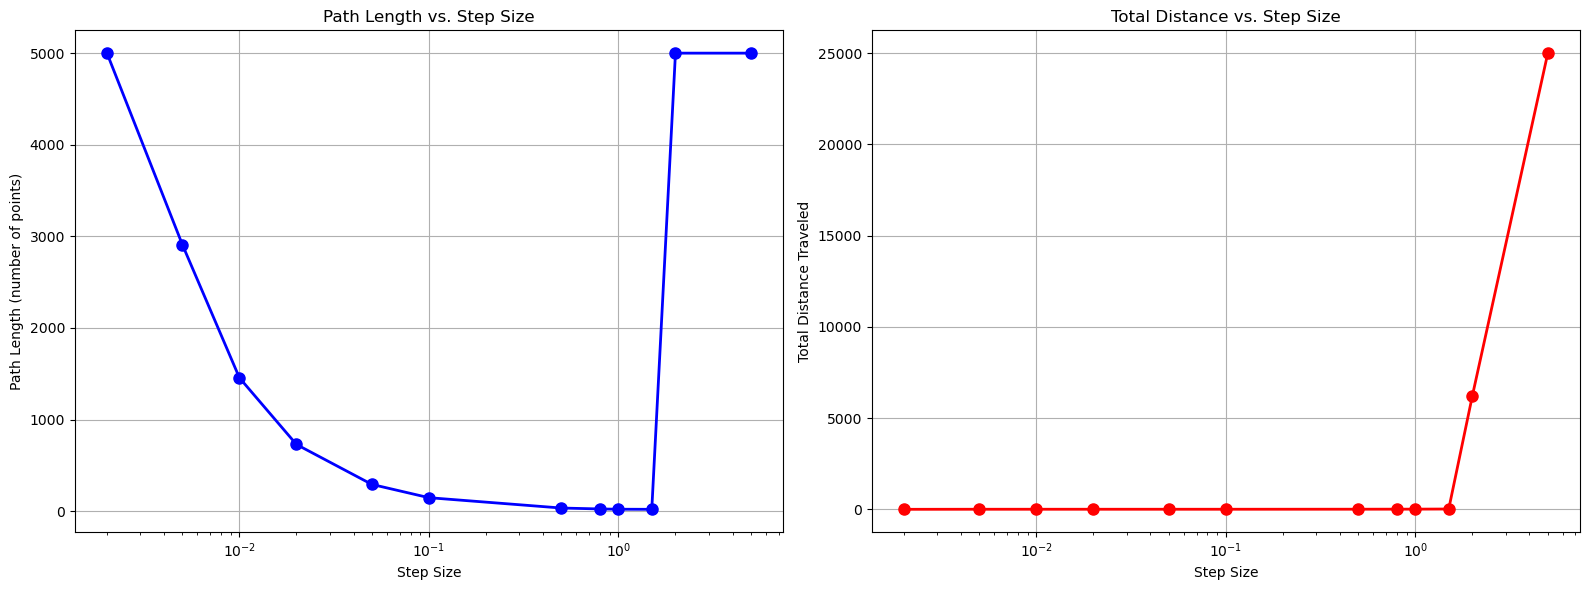


Step Size Results Summary:
------------------------
Step Size    Path Length     Iterations      Total Distance 
---------------------------------------------------------
0.00200      5001            5000            9.99999        
0.00500      2910            2909            13.73789       
0.01000      1456            1455            13.74126       
0.02000      728             727             13.74403       
0.05000      292             291             13.76041       
0.10000      147             146             13.79433       
0.50000      34              33              15.89686       
0.80000      24              23              18.29967       
1.00000      21              20              19.67802       
1.50000      20              19              26.41303       
2.00000      5001            5000            6233.85542     
5.00000      5001            5000            25000.00000    


In [6]:
def plot_step_size_comparison(start, goal, obstacles, threshold, step_sizes=[0.05, 0.1, 0.2, 0.5]):
    """Plot path length and total distance as a function of step size."""
    # Lists to store results
    path_lengths = []
    total_distances = []
    iterations_to_goal = []
    
    # Calculate paths for each step size
    for step in step_sizes:
        path = plan_path(start, goal, obstacles, threshold, step_size=step)
        path_length = len(path)
        total_distance = sum([torch.norm(path[i+1]-path[i]).item() for i in range(path_length-1)])
        
        path_lengths.append(path_length)
        total_distances.append(total_distance)
        iterations_to_goal.append(path_length - 1)  # -1 because path includes start point
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot path length vs step size
    ax1.plot(step_sizes, path_lengths, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Step Size')
    ax1.set_ylabel('Path Length (number of points)')
    ax1.set_title('Path Length vs. Step Size')
    ax1.grid(True)
    # Use log scale for x-axis if step sizes span several orders of magnitude
    if max(step_sizes) / min(step_sizes) > 100:
        ax1.set_xscale('log')
    
    # Plot total distance vs step size
    ax2.plot(step_sizes, total_distances, 'ro-', linewidth=2, markersize=8)
    ax2.set_xlabel('Step Size')
    ax2.set_ylabel('Total Distance Traveled')
    ax2.set_title('Total Distance vs. Step Size')
    ax2.grid(True)
    # Use log scale for x-axis if step sizes span several orders of magnitude
    if max(step_sizes) / min(step_sizes) > 100:
        ax2.set_xscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # Create a table of results
    print("\nStep Size Results Summary:")
    print("------------------------")
    print(f"{'Step Size':<12} {'Path Length':<15} {'Iterations':<15} {'Total Distance':<15}")
    print("-" * 57)
    for i, step in enumerate(step_sizes):
        print(f"{step:<12.5f} {path_lengths[i]:<15} {iterations_to_goal[i]:<15} {total_distances[i]:<15.5f}")

# Example usage
plot_step_size_comparison(Start, Goal, Obstacles, Threshold, 
                        [0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.5, 0.8, 1.0, 1.5, 2.0, 5.0])